#task 1

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster_NoScaling  Cluster_WithScaling  
0                  2                    2  
1                  2                    2  
2                  0                    2  
3                  2                    2  
4                  0                    1  


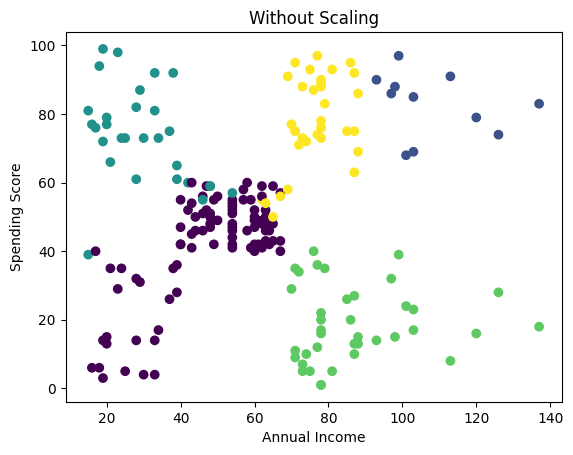

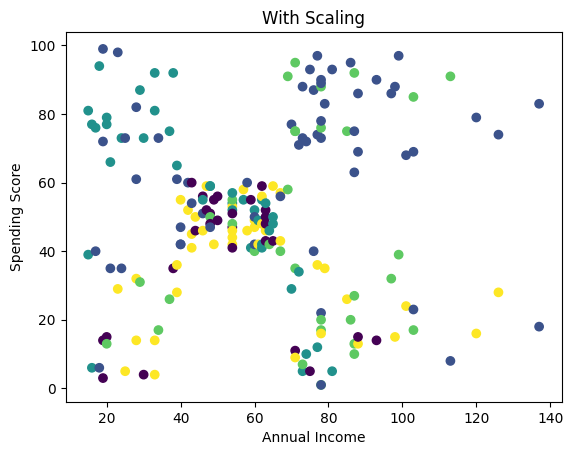

In [5]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("Mall_Customers.csv")

df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

x = df.iloc[:, 1:].values

kmeans1 = KMeans(n_clusters=5, random_state=42)
y1 = kmeans1.fit_predict(x)

scaler = StandardScaler()
x_scaled = x.copy()
x_scaled[:, [0,2,3]] = scaler.fit_transform(x_scaled[:, [0,2,3]])

kmeans2 = KMeans(n_clusters=5, random_state=42)
y2 = kmeans2.fit_predict(x_scaled)

df['Cluster_NoScaling'] = y1
df['Cluster_WithScaling'] = y2

print(df.head())
plt.scatter(x[:,2], x[:,3], c=y1)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Without Scaling")
plt.show()

plt.scatter(x[:,2], x[:,3], c=y2)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("With Scaling")
plt.show()

#task 2

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  \
0                  5   150000               15              5000   
1                  3   120000               18              4000   
2                  8   250000               10              7000   
3                  2    80000               22              2000   
4                  4   100000               20              3000   
5                  7   220000               12              6500   
6                  6   180000               16              5500   
7                 10   300000                8              8000   
8                  1    75000               24              1500   
9                  9   280000                9              7500   

   vehicle_type  Cluster_NoScaling  Cluster_WithScaling  
0             0                  2                    2  
1             1                  2                    2  
2             2                  1                    1  
3             3    

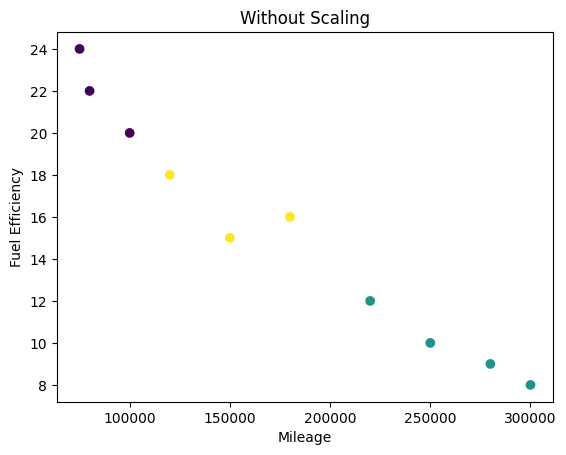

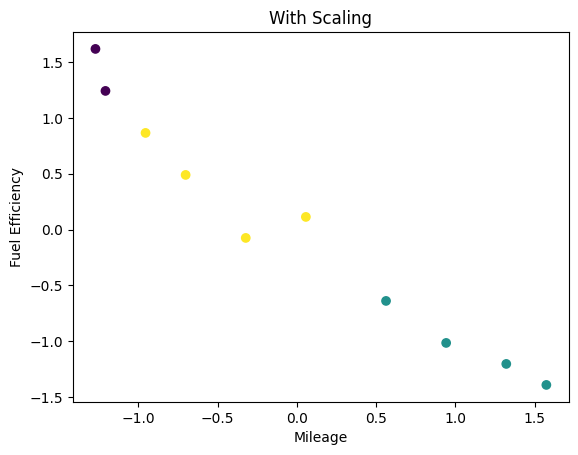

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)

type_map = {'SUV':0, 'Sedan':1, 'Truck':2, 'Hatchback':3}
df['vehicle_type'] = df['vehicle_type'].map(type_map)

x = df.values

kmeans1 = KMeans(n_clusters=3, random_state=42)
y1 = kmeans1.fit_predict(x)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

kmeans2 = KMeans(n_clusters=3, random_state=42)
y2 = kmeans2.fit_predict(x_scaled)

df['Cluster_NoScaling'] = y1
df['Cluster_WithScaling'] = y2

print(df)


plt.scatter(x[:,1], x[:,2], c=y1)
plt.xlabel("Mileage")
plt.ylabel("Fuel Efficiency")
plt.title("Without Scaling")
plt.show()

plt.scatter(x_scaled[:,1], x_scaled[:,2], c=y2)
plt.xlabel("Mileage")
plt.ylabel("Fuel Efficiency")
plt.title("With Scaling")
plt.show()

#task 3

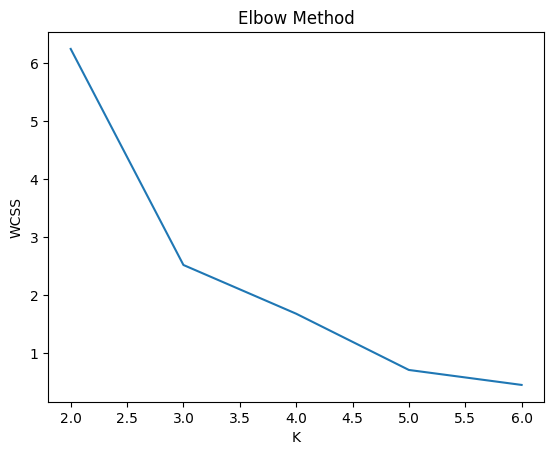

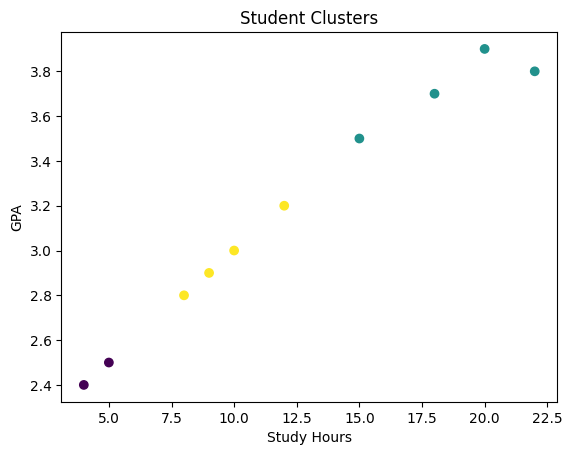

   student_id  GPA  study_hours  attendance_rate  Cluster
0           1  3.5           15               85        1
1           2  2.8            8               60        2
2           3  3.9           20               95        1
3           4  2.5            5               55        0
4           5  3.2           12               75        2
5           6  3.7           18               90        1
6           7  2.9            9               65        2
7           8  3.8           22               92        1
8           9  2.4            4               50        0
9          10  3.0           10               70        2


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id':[1,2,3,4,5,6,7,8,9,10],
    'GPA':[3.5,2.8,3.9,2.5,3.2,3.7,2.9,3.8,2.4,3.0],
    'study_hours':[15,8,20,5,12,18,9,22,4,10],
    'attendance_rate':[85,60,95,55,75,90,65,92,50,70]
}
df = pd.DataFrame(data)

x = df[['GPA','study_hours','attendance_rate']].values

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss = []
for i in range(2,7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,7), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
y = kmeans.fit_predict(x_scaled)

df['Cluster'] = y

plt.scatter(df['study_hours'], df['GPA'], c=y)
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Student Clusters")
plt.show()

print(df)